In [2]:
from google.colab import files
files.upload()

Saving archive.zip to archive (1).zip


{'archive (1).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00@qCO\xc7\xec\xa4[\xff\xff\xff\xff\xff\xff\xff\xff\x12\x00\x14\x00Mall_Customers.csv\x01\x00\x10\x00\x8d\x0f\x00\x00\x00\x00\x00\x00\x81\x05\x00\x00\x00\x00\x00\x00]W\xcb\xae\\E\x0c\xdc\x8f4\xffp\x17,\x88t\x90\xfa\xfdXF P\x16\xac\xf2\x05Q\x18E\x88d\x82.\xe4\xff\xa9\xaa~\xb8\xc3nT\xe3v\x97\xcbv\xdb\xe7\xe7o\xff\xfc\xfb\xf5\xcb\xe3\xf5\xdd/\xd7o\x8f\xe7\x1f\x8f\xd7\xeb\xed\xa7\xc7\xf5\xf6\xf9\xfc\xf6\xe1\xf3\xcb\xbb\xe7G\xfc\xf7\xf2\xe3_?\xbc\xb9\xde\xff\x8d\xbf\xff|~zy\xff\xf1\xeb+0\xff\x93w\xee\xcd\xfd\xe6\xaf\xdf?|~\\\xbe_>_\xb1\xdfoa\x00\xc1\x13h\xfe~\x8b\xd7\xaf\x8f/\x82\xdc\xe5\xcbU\xee\xb7\xb4\x91H\xa4\xd6\xfb-/(\xe2\\\xbd\x92\xbb\xdf\xca\xb6\n\x84*\x0e\xd6m\x95/\xdf\xe8\xaa\x9d\xae\xda\xd5\xd3\xfd\xd6\x07\x81\x92H*\x82\xa1\xdb\xa7\x1c\xa1\x1a\x80M\xda\xa5\x8a9N\xf9p\xfa\xeeWG(~S\xcfM\xec30#\x9f\x88\x91<\x02\x95\xb7Xe\xc5;\xcbT!\xc8\x86\xbeN\xee\x10\'\xd2W\x9bV\x8eHA8~\x92\xcf\x81\x01\x05\xca\xe9\xces\xf1\xea\r\xd8dO$\xc9SX\xaa\x

In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
import os
os.listdir()

['.config',
 'archive (1).zip',
 'Mall_Customers.csv',
 'archive.zip',
 'sample_data']

In [5]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Convert Gender to numeric
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Select features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

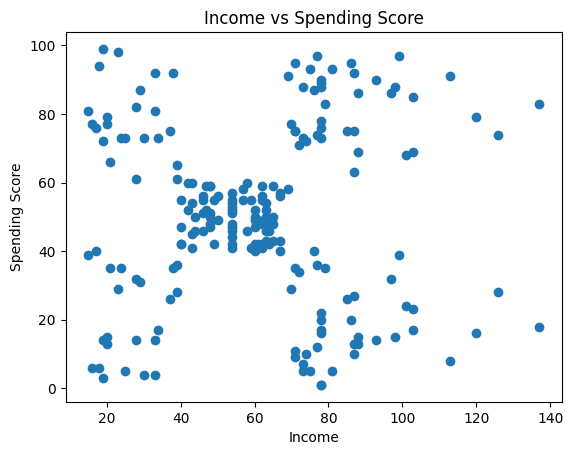

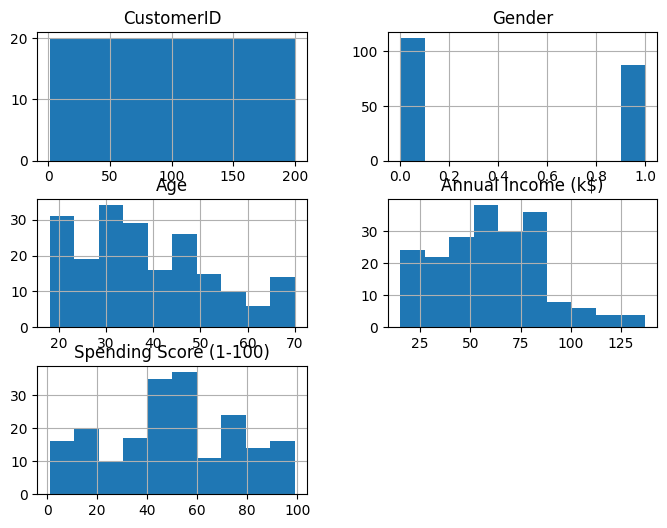

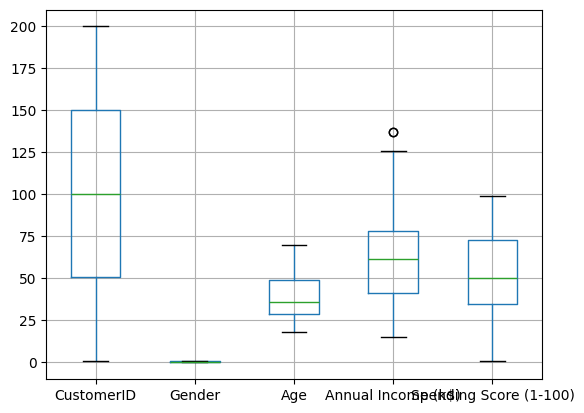

In [7]:
import matplotlib.pyplot as plt

# 1. Scatter Plot
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title("Income vs Spending Score")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

# 2. Histogram
df.hist(figsize=(8,6))
plt.show()

# 3. Box Plot
df.boxplot()
plt.show()

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0)
y_pred = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_pred

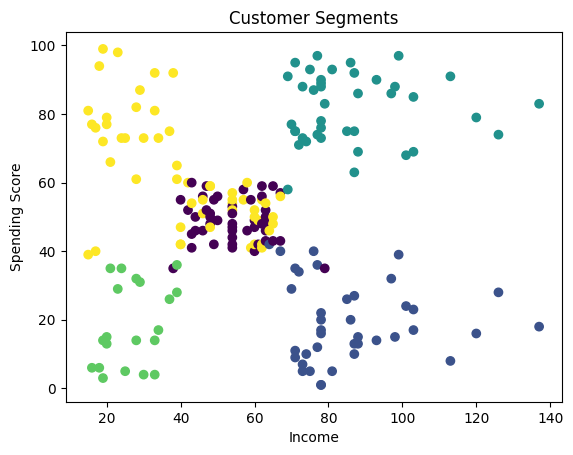

In [9]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_pred)
print("Silhouette Score:", score)

Silhouette Score: 0.41664341513732767
